In [39]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.ndimage import zoom # for rescaling
from scipy.ndimage import convolve # for blurring/smoothing

# image_name = input("Enter image name: ")
img = Image.open("images/Prof.jpg").convert("L")
img_array = np.array(img)

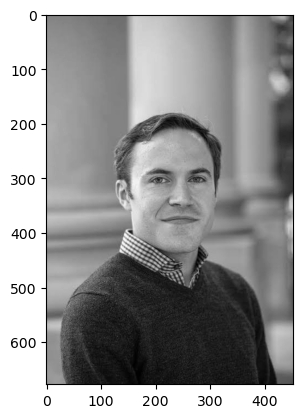

In [40]:
#just show regular image
plt.imshow(img_array, cmap='gray')
plt.axis('on')
plt.show()

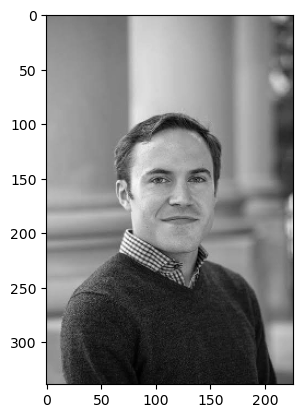

In [41]:
# rescale image

# set scaling factor
scaling_factor = 0.5

scaled_img = zoom(img_array, (scaling_factor, scaling_factor))

# display rescaled image
plt.imshow(scaled_img, cmap='gray')
plt.axis('on')
plt.show()

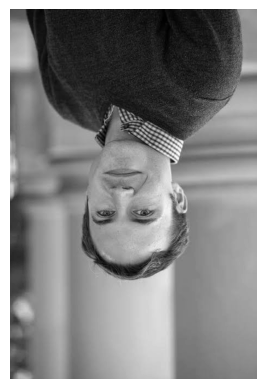

In [42]:
# rotate image

# select whatever rotation wanted
rotated_img = img.rotate(180) 

rotated_img_array = np.array(rotated_img)

# display rotated image
plt.imshow(rotated_img_array, cmap='gray')
plt.axis('off')
plt.show()

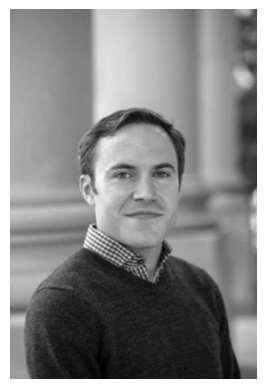

In [49]:
# smoothing:

kernel = np.ones((3, 3)) / 9

# sharpen:

# kernel = np.array([
#     [ 0, -1,  0],
#     [-1,  5, -1],
#     [ 0, -1,  0]
# ])

# edge detection:

# vertical:

# kernel = np.array([
#     [-1, 0, 1],
#     [-2, 0, 2],
#     [-1, 0, 1]
# ])

# horisontal:

# kernel = np.array([
#     [-1, -2, -1],
#     [ 0,  0,  0],
#     [ 1,  2,  1]
# ])


# apply convolution
blurred_img_array = convolve(img_array, kernel)

# Display blurred image
plt.imshow(blurred_img_array, cmap='gray')
plt.axis('off')
plt.show()

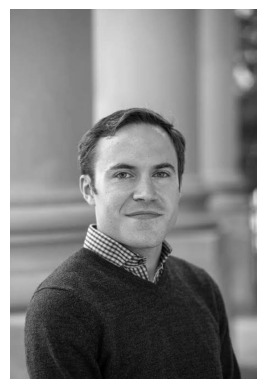

In [8]:
# Perform SVD on the image matrix
U, S, Vt = np.linalg.svd(img_array)

# Keep only the top k singular values (compression)
k = 452  # Keep only the first 50 singular values

# Create a diagonal matrix for the first k singular values
S_k = np.zeros((U.shape[0], Vt.shape[0]))  # Initialize S_k with the correct shape
S_k[:k, :k] = np.diag(S[:k])  # Place the first k singular values on the diagonal

# Reconstruct the image using the reduced singular values
img_reconstructed = np.dot(U, np.dot(S_k, Vt))

# Display the compressed image
plt.imshow(img_reconstructed, cmap='gray')
plt.axis('off')
plt.show()


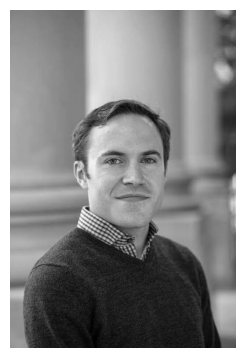

In [29]:
# Perform SVD on the image matrix
U, S, Vt = np.linalg.svd(img_array)

# Choose the number of singular values to keep (lower values = more compression, higher = less compression)
k = 452  # Experiment with different values of k (e.g., 50, 100, 150)

# Create the diagonal matrix for the top k singular values
S_k = np.zeros((U.shape[0], Vt.shape[0]))  # Initialize with the correct shape
S_k[:k, :k] = np.diag(S[:k])  # Place the top k singular values in the diagonal

# Reconstruct the image using the reduced singular values
img_reconstructed = np.dot(U, np.dot(S_k, Vt))

# Enhanced image (SVD-based reconstruction)
plt.subplot(1, 2, 2)
plt.imshow(img_reconstructed, cmap='gray')
# plt.title(f"Enhanced Image (k={k})")
plt.axis('off')

plt.show()